In [ ]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rc, cm
import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras.optimizers import Adam, SGD

2026-04-21 13:35:20.936175: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-21 13:35:20.960884: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-21 13:35:20.960907: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-21 13:35:20.961526: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-21 13:35:20.965685: I tensorflow/core/platform/cpu_feature_guar

2026-04-21 13:35:23.476687: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-04-21 13:35:23.476704: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:129] retrieving CUDA diagnostic information for host: cf6efd995173
2026-04-21 13:35:23.476707: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:136] hostname: cf6efd995173
2026-04-21 13:35:23.476758: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:159] libcuda reported version is: 580.126.9
2026-04-21 13:35:23.476772: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] kernel reported version is: 580.126.9
2026-04-21 13:35:23.476774: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:241] kernel version seems to match DSO: 580.126.9


Epoch 1/2000
2/2 [==============================] - 0s 4ms/step - loss: 0.3378 - mse: 0.3378
Epoch 2/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3375 - mse: 0.3375
Epoch 3/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3373 - mse: 0.3373
Epoch 4/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3371 - mse: 0.3371
Epoch 5/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3369 - mse: 0.3369
Epoch 6/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3367 - mse: 0.3367
Epoch 7/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3365 - mse: 0.3365
Epoch 8/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3362 - mse: 0.3362
Epoch 9/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3360 - mse: 0.3360
Epoch 10/2000
2/2 [==============================] - 0s 1ms/step - loss: 0.3358 - mse: 0.3358
Epoch 11/2000
2/2 [==============================] - 0s 1ms/step - lo

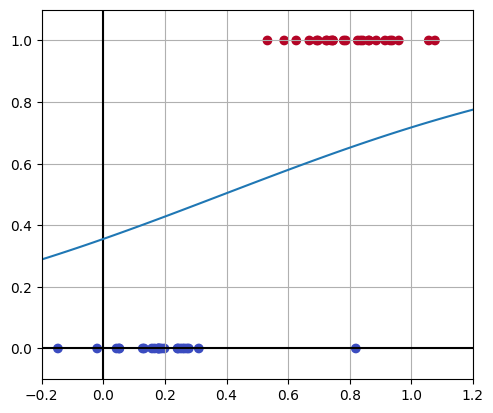

In [2]:
# --- 첫 번째 사진: 데이터 준비 및 모델 학습 ---

def prepare_data(n=10, test=0.5, sigma=0.15):
    n1 = int(n/2)
    n2 = n - n1
    
    # 클래스 0 데이터 생성 (평균 0.2 근처)
    x1 = np.random.normal(loc=0.2, scale=sigma, size=n1)
    y1 = np.random.normal(loc=0.0, scale=0.0, size=n1) # y값은 0
    
    # 클래스 1 데이터 생성 (평균 0.8 근처)
    x2 = np.random.normal(loc=0.8, scale=sigma, size=n2)
    y2 = np.random.normal(loc=1.0, scale=0.0, size=n2) # y값은 1
    
    x = np.concatenate((x1, x2))
    y = np.concatenate((y1, y2))
    return (x, y)

# 50개의 데이터 생성
(x_train, y_train) = prepare_data(n=50)

# 모델 구성: 입력 1개 -> Dense(1개, 시그모이드 활성화)
input_layer = Input((1,))
output_layer = Dense(1, activation='sigmoid')(input_layer)
model = Model(input_layer, output_layer)

# 모델 설정 및 학습
model.compile(loss='mean_squared_error', optimizer=SGD(lr=0.1), metrics=['mse'])
model.fit(x_train, y_train, epochs=2000)


# --- 두 번째 사진: 결과 시각화 ---

# 학습된 가중치(w)와 편향(b) 추출
layer = model.layers[1]
weights = layer.get_weights()
w = weights[0][0][0]
b = weights[1][0]

fig, ax = plt.subplots()
ax.set_aspect('equal')
ax.grid(True, which='both')
ax.axhline(y=0, color='k')
ax.axvline(x=0, color='k')
ax.axis([-0.2, 1.2, -0.1, 1.1])

# 데이터 산점도
ax.scatter(x_train, y_train, c=y_train, cmap=cm.coolwarm)

# 시그모이드 곡선 그리기
x = np.linspace(-0.2, 1.2, 51)
z = w * x + b
y = 1 / (1 + np.exp(-z)) # 시그모이드 함수 공식: 1 / (1 + e^-z)
ax.plot(x, y)

# 결과 확인
# plt.show() # 터미널 환경이라면 아래 savefig를 사용하세요.
plt.savefig('logistic_result.png')